## 1. Importación de librerías y carga de datasets

In [43]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv('Datasets/train.csv')
df_test = pd.read_csv('Datasets/test.csv')
data_dict = pd.read_csv('Datasets/data_dictionary.csv')

df.shape

(3960, 82)

**Conclusiones:**
- Librerías cargadas correctamente: pandas, numpy, matplotlib, seaborn
- Datasets cargados: `train.csv` (principal), `test.csv` (para ML futuro), `data_dictionary.csv` (referencia de columnas)
- El dataset tiene 3.960 filas (participantes) y 82 columnas (variables)
- Es un dataset amplio, será necesario filtrar columnas relevantes para el análisis

## 2. Exploración de las columnas disponibles

In [44]:
df.columns

Index(['id', 'Basic_Demos-Enroll_Season', 'Basic_Demos-Age', 'Basic_Demos-Sex',
       'CGAS-Season', 'CGAS-CGAS_Score', 'Physical-Season', 'Physical-BMI',
       'Physical-Height', 'Physical-Weight', 'Physical-Waist_Circumference',
       'Physical-Diastolic_BP', 'Physical-HeartRate', 'Physical-Systolic_BP',
       'Fitness_Endurance-Season', 'Fitness_Endurance-Max_Stage',
       'Fitness_Endurance-Time_Mins', 'Fitness_Endurance-Time_Sec',
       'FGC-Season', 'FGC-FGC_CU', 'FGC-FGC_CU_Zone', 'FGC-FGC_GSND',
       'FGC-FGC_GSND_Zone', 'FGC-FGC_GSD', 'FGC-FGC_GSD_Zone', 'FGC-FGC_PU',
       'FGC-FGC_PU_Zone', 'FGC-FGC_SRL', 'FGC-FGC_SRL_Zone', 'FGC-FGC_SRR',
       'FGC-FGC_SRR_Zone', 'FGC-FGC_TL', 'FGC-FGC_TL_Zone', 'BIA-Season',
       'BIA-BIA_Activity_Level_num', 'BIA-BIA_BMC', 'BIA-BIA_BMI',
       'BIA-BIA_BMR', 'BIA-BIA_DEE', 'BIA-BIA_ECW', 'BIA-BIA_FFM',
       'BIA-BIA_FFMI', 'BIA-BIA_FMI', 'BIA-BIA_Fat', 'BIA-BIA_Frame_num',
       'BIA-BIA_ICW', 'BIA-BIA_LDM', 'BIA-BIA_LST'

**Conclusiones:**
- Las 82 columnas se agrupan en 9 bloques temáticos según su prefijo
- Bloques más relevantes para el proyecto: `PreInt_EduHx-` (horas de pantalla), `PCIAT-` (uso problemático de internet), `CGAS-` (salud mental general), `SDS-` (sueño) y `sii` (posible variable objetivo)
- Bloques de menor relevancia directa: `BIA-`, `FGC-`, `Fitness_Endurance-` (medidas físicas/composición corporal)

## 3. Tipos de datos y valores nulos

In [45]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 3960 entries, 0 to 3959
Data columns (total 82 columns):
 #   Column                                  Non-Null Count  Dtype  
---  ------                                  --------------  -----  
 0   id                                      3960 non-null   str    
 1   Basic_Demos-Enroll_Season               3960 non-null   str    
 2   Basic_Demos-Age                         3960 non-null   int64  
 3   Basic_Demos-Sex                         3960 non-null   int64  
 4   CGAS-Season                             2555 non-null   str    
 5   CGAS-CGAS_Score                         2421 non-null   float64
 6   Physical-Season                         3310 non-null   str    
 7   Physical-BMI                            3022 non-null   float64
 8   Physical-Height                         3027 non-null   float64
 9   Physical-Weight                         3076 non-null   float64
 10  Physical-Waist_Circumference            898 non-null    float64
 11  Ph

**Conclusiones:**

- Hay 3 tipos de datos: `int64` (2 columnas), `float64` (68 columnas) y `str`/objeto (12 columnas)

- **Valores nulos muy desiguales por bloque:**
  - `Basic_Demos-*` (edad, sexo): 0 nulos → 3960/3960 completos
  - `PCIAT-*` (uso problemático de internet): ~1.220-1.235 nulos por columna (solo ~2730/3960 respondieron)
  - `sii` (variable objetivo): 1.224 nulos (solo 2736/3960 tienen valor)
  - `PreInt_EduHx-computerinternet_hoursday` (horas de pantalla): 659 nulos (3301/3960)
  - `CGAS-CGAS_Score`: 1.539 nulos (solo 2421/3960)
  - `SDS-*` (sueño): ~1.350 nulos (solo ~2606-2618/3960)
  - `BIA-*` (composición corporal): ~1.969 nulos (solo 1991/3960) → casi la mitad sin datos
  - `Fitness_Endurance-*`: ~3.220 nulos (solo 740-743/3960) → más de un 80% sin datos
  - `PAQ_A-*`: 3.485 nulos (solo 475/3960) → casi vacío

- **Implicación clave:** las columnas más relevantes para el proyecto (`PCIAT`, `sii`, `SDS`, `CGAS`, `PreInt_EduHx`) tienen entre el 30% y el 40% de valores nulos. Habrá que decidir cómo tratarlos (eliminar filas, imputar valores, o trabajar solo con los registros completos)

- Las columnas `BIA-*`, `Fitness_Endurance-*` y `PAQ_A-*` tienen tantos nulos que probablemente no sean útiles para el análisis principal

## 4. Selección de columnas relevantes

Reducimos el dataset a las 8 columnas clave para el Dashboard 2 
(demografía, horas de pantalla, salud mental y variable objetivo), 
descartando bloques con muchos nulos y poco relacionados con el proyecto.

In [46]:
columnas_relevantes = [
    'id',
    'Basic_Demos-Age',
    'Basic_Demos-Sex',
    'PreInt_EduHx-computerinternet_hoursday',
    'PCIAT-PCIAT_Total',
    'CGAS-CGAS_Score',
    'SDS-SDS_Total_T',
    'sii'
]

df_reducido = df[columnas_relevantes]
df_reducido.head()

,id,Basic_Demos-Age,Basic_Demos-Sex,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,CGAS-CGAS_Score,SDS-SDS_Total_T,sii
0,00008ff9,5,0,3.0,55.0,51.0,NaN,2.0
1,000fd460,9,0,0.0,0.0,NaN,64.0,0.0
2,00105258,10,1,2.0,28.0,71.0,54.0,0.0
3,00115b9f,9,0,0.0,44.0,71.0,45.0,1.0
4,0016bb22,18,1,NaN,NaN,NaN,NaN,NaN


**Conclusiones:**

- El DataFrame reducido tiene 8 columnas y mantiene los datos originales correctamente
- Se confirma la presencia de NaN incluso en las columnas clave: la fila 4 (id 0016bb22) 
  no tiene datos en PreInt_EduHx, PCIAT_Total, CGAS_Score, SDS_Total_T ni sii
- `Basic_Demos-Sex` aparece codificado como 0/1 (probablemente 0=uno de los sexos, 1=el otro), 
  habrá que confirmar el significado exacto en data_dictionary.csv
- `sii` también está en formato decimal (0.0, 1.0, 2.0, NaN), aunque parece ser una 
  variable categórica (niveles de severidad)

## 5. Significado de Sex y sii según el diccionario de datos

Antes de seguir, confirmamos en data_dictionary.csv qué representan 
los valores 0/1 de Basic_Demos-Sex y los niveles 0-3 de sii.

In [47]:
data_dict[data_dict['Field'].isin(['Basic_Demos-Sex', 'sii'])]

,Instrument,Field,Description,Type,Values,Value Labels
3,Demographics,Basic_Demos-Sex,Sex of participant,categorical int,"0,1","0=Male, 1=Female"


**Conclusiones:**

- `Basic_Demos-Sex`: 0 = Male (hombre/niño), 1 = Female (mujer/niña)
- La fila para `sii` no aparece en este resultado, no está en data_dictionary.csv 
  con ese nombre exacto, o hay que buscarla de otra forma

## 6. Búsqueda de la variable objetivo "sii" en el diccionario

sii no apareció en la búsqueda anterior. Buscamos cualquier fila 
que contenga "sii" o "Severity" para entender qué representa.

In [48]:
data_dict[data_dict['Field'].str.contains('sii', case=False, na=False) | 
          data_dict['Description'].str.contains('severity|impairment', case=False, na=False)]

,Instrument,Field,Description,Type,Values,Value Labels


**Conclusiones:**

- La búsqueda devuelve un resultado vacío: "sii" no aparece en data_dictionary.csv
- sii es la variable objetivo de la competición (Severity Impairment Index), 
  calculada por los organizadores a partir del PCIAT-PCIAT_Total, 
  no forma parte del cuestionario original
- Según la documentación de la competición, sii se deriva directamente 
  de PCIAT_Total en 4 niveles de severidad: 0=Ninguno, 1=Leve, 2=Moderado, 3=Severo

## 7. Relación entre PCIAT_Total y sii

Comprobamos cómo se relacionan los valores de PCIAT-PCIAT_Total 
con los niveles de sii, para entender cómo se construye la variable objetivo.

In [49]:
df_reducido.groupby('sii')['PCIAT-PCIAT_Total'].agg(['min', 'max', 'count'])

,min,max,count
sii,,,
0.0,0.0,30.0,1594
1.0,31.0,49.0,730
2.0,50.0,79.0,378
3.0,80.0,93.0,34


**Conclusiones:**

- Se confirma que sii es una variable derivada directamente de PCIAT-PCIAT_Total, 
  dividida en 4 rangos de severidad:
  - sii=0 (Ninguno): PCIAT_Total entre 0-30 → 1.594 casos
  - sii=1 (Leve): PCIAT_Total entre 31-49 → 730 casos
  - sii=2 (Moderado): PCIAT_Total entre 50-79 → 378 casos
  - sii=3 (Severo): PCIAT_Total entre 80-93 → 34 casos

- Los datos están muy desbalanceados: el 58% de los casos son "sii=0" (ninguno), 
  y solo un 1.2% son "sii=3" (severo). Esto será importante a tener en cuenta 
  más adelante si se usa sii como variable objetivo para un modelo de ML 
  (problema de clases desbalanceadas)

- Total de casos con sii calculado: 1594+730+378+34 = 2.736, 
  coincide con el número de no-nulos visto en el paso 3

## 8. Distribución de valores nulos en df_reducido

Cuantificamos los nulos en las columnas seleccionadas para decidir 
cómo tratarlos (eliminar filas, imputar, o trabajar con subconjuntos).

In [50]:
df_reducido.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
PreInt_EduHx-computerinternet_hoursday     659
PCIAT-PCIAT_Total                         1224
CGAS-CGAS_Score                           1539
SDS-SDS_Total_T                           1354
sii                                       1224
dtype: int64

**Conclusiones:**

- id, Basic_Demos-Age y Basic_Demos-Sex: sin nulos (100% completos)
- PreInt_EduHx-computerinternet_hoursday: 659 nulos (16.6%)
- PCIAT-PCIAT_Total y sii: 1.224 nulos cada una (30.9%) — mismo número, 
  confirma que sii depende de PCIAT_Total (si uno falta, falta el otro)
- CGAS-CGAS_Score: 1.539 nulos (38.9%) — la columna con más nulos
- SDS-SDS_Total_T: 1.354 nulos (34.2%)

- Si eliminamos todas las filas con algún nulo (dropna), perderíamos 
  probablemente más del 40% del dataset. Hay que decidir una estrategia:
  - Opción A: trabajar solo con filas completas (dataset más pequeño pero limpio)
  - Opción B: analizar cada pregunta con el subconjunto de columnas que necesite 
    (sin descartar todo el dataset de golpe)
  - Opción C: imputar valores (rellenar nulos con media/mediana)

## 9. Imputación de valores nulos con la mediana

Rellenamos los nulos de las columnas numéricas (horas de pantalla, 
PCIAT_Total, CGAS_Score, SDS_Total_T) con la mediana de cada columna, 
para conservar las 3.960 filas sin perder información.

In [51]:
columnas_a_imputar = [
    'PreInt_EduHx-computerinternet_hoursday',
    'PCIAT-PCIAT_Total',
    'CGAS-CGAS_Score',
    'SDS-SDS_Total_T'
]

for col in columnas_a_imputar:
    mediana = df_reducido[col].median()
    df_reducido[col] = df_reducido[col].fillna(mediana)

df_reducido.isnull().sum()

id                                           0
Basic_Demos-Age                              0
Basic_Demos-Sex                              0
PreInt_EduHx-computerinternet_hoursday       0
PCIAT-PCIAT_Total                            0
CGAS-CGAS_Score                              0
SDS-SDS_Total_T                              0
sii                                       1224
dtype: int64

**Conclusiones:**

- Las 4 columnas imputadas (horas de pantalla, PCIAT_Total, CGAS_Score, SDS_Total_T) 
  ya no tienen nulos
- sii sigue con 1.224 nulos, como esperábamos: no se imputó porque depende de 
  PCIAT_Total y debe recalcularse, no rellenarse con su propia mediana

## 10. Recalcular sii a partir de PCIAT_Total imputado

Aplicamos los mismos rangos vistos en el paso 7 (0-30→0, 31-49→1, 
50-79→2, 80-93→3) para recalcular sii en las filas donde faltaba, 
ahora que PCIAT_Total ya no tiene nulos.

In [52]:
def calcular_sii(pciat_total):
    if pciat_total <= 30:
        return 0
    elif pciat_total <= 49:
        return 1
    elif pciat_total <= 79:
        return 2
    else:
        return 3

df_reducido['sii'] = df_reducido['PCIAT-PCIAT_Total'].apply(calcular_sii)
df_reducido.isnull().sum()

id                                        0
Basic_Demos-Age                           0
Basic_Demos-Sex                           0
PreInt_EduHx-computerinternet_hoursday    0
PCIAT-PCIAT_Total                         0
CGAS-CGAS_Score                           0
SDS-SDS_Total_T                           0
sii                                       0
dtype: int64

**Conclusiones:**

- df_reducido ya no tiene ningún valor nulo en sus 8 columnas (3.960 filas completas)
- sii ha sido recalculado correctamente a partir de PCIAT_Total, manteniendo 
  la coherencia entre ambas variables
- El dataset está limpio y listo para continuar con el análisis exploratorio 
  (estadísticas descriptivas, distribuciones, correlaciones)

## 11. Estadísticas descriptivas generales

Vemos media, mediana, mínimos, máximos y desviación estándar 
de las variables numéricas, para entender rangos y detectar posibles outliers.

In [53]:
df_reducido.describe()

,Basic_Demos-Age,Basic_Demos-Sex,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,CGAS-CGAS_Score,SDS-SDS_Total_T,sii
count,3960.000000,3960.000000,3960.000000,3960.000000,3960.00000,3960.000000,3960.00000
mean,10.433586,0.372727,1.050505,27.310101,65.27803,56.818687,0.40101
std,3.574648,0.483591,0.999861,16.927592,17.46905,10.784249,0.69480
min,5.000000,0.000000,0.000000,0.000000,25.00000,38.000000,0.00000
25%,8.000000,0.000000,0.000000,20.000000,61.00000,51.000000,0.00000
50%,10.000000,0.000000,1.000000,26.000000,65.00000,55.000000,0.00000
75%,13.000000,1.000000,2.000000,33.000000,68.00000,59.000000,1.00000
max,22.000000,1.000000,3.000000,93.000000,999.00000,100.000000,3.00000


**Conclusiones:**

- Edad (Basic_Demos-Age): rango 5-22 años, media ~10.4 años. 
  ⚠️ Hay valores hasta 22, fuera del rango "0-18 años" que define nuestro proyecto

- Sexo (Basic_Demos-Sex): media 0.37 → aproximadamente 63% son hombres (0) 
  y 37% mujeres (1), dataset desbalanceado por sexo

- Horas de pantalla (PreInt_EduHx-computerinternet_hoursday): rango 0-3, 
  media ~1.05. Esto es sospechoso: parece una escala categórica/codificada 
  (0,1,2,3) y no "horas reales" — habrá que verificar su significado exacto 
  en data_dictionary.csv

- PCIAT_Total: rango 0-93, media ~27.3, coherente con lo visto antes

- CGAS_Score: rango 25-999, media ~65.3. 
  ⚠️ El valor máximo de 999 es claramente un valor erróneo/placeholder 
  (la escala CGAS real va de 0 a 100). Es un outlier que distorsiona 
  la media y habrá que corregir

- SDS_Total_T: rango 38-100, media ~56.8, valores dentro de un rango plausible

- sii: rango 0-3, media ~0.40, coherente con la distribución vista antes 
  (mayoría en nivel 0)

## 12. Significado real de "horas de pantalla" según el diccionario

Verificamos en data_dictionary.csv qué representan exactamente 
los valores 0-3 de PreInt_EduHx-computerinternet_hoursday.

In [54]:
data_dict[data_dict['Field'] == 'PreInt_EduHx-computerinternet_hoursday']

,Instrument,Field,Description,Type,Values,Value Labels
80,Internet Use,PreInt_EduHx-computerinternet_hoursday,Hours of using computer/internet,categorical int,"0,1,2,3","0=Less than 1h/day, 1=Around 1h/day, 2=Around ..."


**Conclusiones:**

- PreInt_EduHx-computerinternet_hoursday NO son horas reales, son una 
  variable categórica con 4 niveles:
  - 0 = Menos de 1h/día
  - 1 = Alrededor de 1h/día
  - 2 = Alrededor de 2h/día (probablemente)
  - 3 = Más de 2-3h/día (probablemente, falta confirmar el valor exacto)

- Esto es importante para el Dashboard 2 en Tableau: esta variable debe 
  tratarse como categórica (para gráficos de barras/comparaciones por grupo), 
  no como una variable numérica continua

- Para el análisis y las visualizaciones, conviene crear una nueva columna 
  con las etiquetas de texto (ej: "Menos de 1h", "Alrededor de 1h"...) 
  en lugar de solo los números 0-3, para que sea más legible

## 13. Etiquetas completas de las categorías de horas de pantalla

El resultado anterior aparece cortado ("..."). Obtenemos el texto completo 
de Value Labels para las 4 categorías.

In [55]:
data_dict[data_dict['Field'] == 'PreInt_EduHx-computerinternet_hoursday']['Value Labels'].values[0]

'0=Less than 1h/day, 1=Around 1h/day, 2=Around 2hs/day, 3=More than 3hs/day'

**Conclusiones:**

- Las 4 categorías completas de horas de pantalla son:
  - 0 = Menos de 1h/día
  - 1 = Alrededor de 1h/día
  - 2 = Alrededor de 2h/día
  - 3 = Más de 3h/día

- Esta variable queda confirmada como categórica ordinal (hay un orden 
  lógico de menos a más horas), aunque esté codificada como números 0-3

- Para Tableau, será útil crear una columna con estas etiquetas en texto, 
  para que los gráficos sean autoexplicativos sin necesitar leyenda aparte

## 14. Detección del outlier en CGAS_Score

CGAS es una escala de 0-100, pero vimos un máximo de 999 en el describe(). 
Comprobamos cuántas filas tienen este valor erróneo.

In [56]:
df_reducido[df_reducido['CGAS-CGAS_Score'] > 100]

,id,Basic_Demos-Age,Basic_Demos-Sex,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,CGAS-CGAS_Score,SDS-SDS_Total_T,sii
2065,83525bbe,11,1,3.0,26.0,999.0,55.0,0


**Conclusiones:**

- Solo hay 1 fila (de 3.960) con el valor erróneo CGAS_Score=999 (id 83525bbe)
- Al ser un único caso aislado, es seguro tratarlo como un valor faltante 
  y corregirlo sin afectar significativamente al análisis
- La estrategia más coherente es la misma que ya aplicamos: sustituir 
  este valor por la mediana de CGAS_Score (que vimos era 65.0)

## 15. Corrección del outlier en CGAS_Score

Sustituimos el valor erróneo 999 por la mediana de CGAS_Score (65.0), 
manteniendo coherencia con la estrategia de imputación usada antes.

In [57]:
mediana_cgas = df_reducido['CGAS-CGAS_Score'].median()

df_reducido.loc[df_reducido['CGAS-CGAS_Score'] > 100, 'CGAS-CGAS_Score'] = mediana_cgas

df_reducido['CGAS-CGAS_Score'].describe()

count    3960.000000
mean       65.042172
std         9.213885
min        25.000000
25%        61.000000
50%        65.000000
75%        68.000000
max        95.000000
Name: CGAS-CGAS_Score, dtype: float64

## 16. Conversión a tipo entero

Ahora que no hay valores nulos, convertimos las columnas numéricas 
de float64 a int64, ya que todas representan valores enteros 
(edad, sexo, categorías, puntuaciones).

In [58]:
columnas_a_int = [
    'Basic_Demos-Age',
    'Basic_Demos-Sex',
    'PreInt_EduHx-computerinternet_hoursday',
    'PCIAT-PCIAT_Total',
    'CGAS-CGAS_Score',
    'SDS-SDS_Total_T',
    'sii'
]

for col in columnas_a_int:
    df_reducido[col] = df_reducido[col].astype(int)

df_reducido.dtypes

id                                          str
Basic_Demos-Age                           int64
Basic_Demos-Sex                           int64
PreInt_EduHx-computerinternet_hoursday    int64
PCIAT-PCIAT_Total                         int64
CGAS-CGAS_Score                           int64
SDS-SDS_Total_T                           int64
sii                                       int64
dtype: object

**Conclusiones:**

- Todas las columnas numéricas se convirtieron correctamente a int64
- id permanece como str (es un identificador, no debe ser numérico)
- El dataset queda con tipos coherentes para el análisis: enteros para 
  edad, sexo, categorías y puntuaciones

## 17. Revisión del rango de edad

El proyecto se centra en 0-18 años, pero vimos edades hasta 22. 
Comprobamos cuántas filas superan los 18 años.

In [59]:
df_reducido[df_reducido['Basic_Demos-Age'] > 18]

,id,Basic_Demos-Age,Basic_Demos-Sex,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,CGAS-CGAS_Score,SDS-SDS_Total_T,sii
9,0083e397,19,1,1,26,65,55,0
47,0274e7f3,21,1,1,26,50,55,0
65,03e83fef,21,1,2,26,65,55,0
237,0d5e7943,20,1,3,26,65,55,0
257,0ec403df,19,1,3,51,55,55,2
...,...,...,...,...,...,...,...,...
3389,db18f921,19,0,1,26,65,55,0
3395,db4635c4,20,1,2,26,65,55,0
3538,e3f71f7a,20,0,0,6,65,75,0
3678,ed0b3906,19,0,3,67,60,55,2


**Conclusiones:**

- Hay 88 filas (de 3.960, un 2.2%) con edad superior a 18 años (rango 19-22)
- El proyecto se centra en 0-18 años, por lo que estas filas quedan 
  fuera del alcance definido
- Al ser solo el 2.2% del dataset, eliminarlas no afecta significativamente 
  al tamaño ni a la representatividad del análisis

## 18. Eliminación de filas con edad > 18 años

Filtramos el dataset para mantener solo el rango de edad definido 
en el proyecto (0-18 años), eliminando las 88 filas con edades 19-22.

In [60]:
df_reducido = df_reducido[df_reducido['Basic_Demos-Age'] <= 18]
df_reducido.shape

(3872, 8)

**Conclusiones:**

- Dataset filtrado correctamente: de 3.960 a 3.872 filas (eliminadas 88 filas 
  con edad > 18 años)
- El DataFrame queda alineado con el rango de edad definido en el proyecto 
  (0-18 años) y sin nulos, sin outliers conocidos, y con tipos de datos correctos
- df_reducido está listo para el análisis exploratorio visual 
  (distribuciones, correlaciones, comparativas por grupo)

## 19. Distribución de edades en el dataset

Visualizamos cómo se distribuyen las edades de los participantes 
(0-18 años) con un histograma.

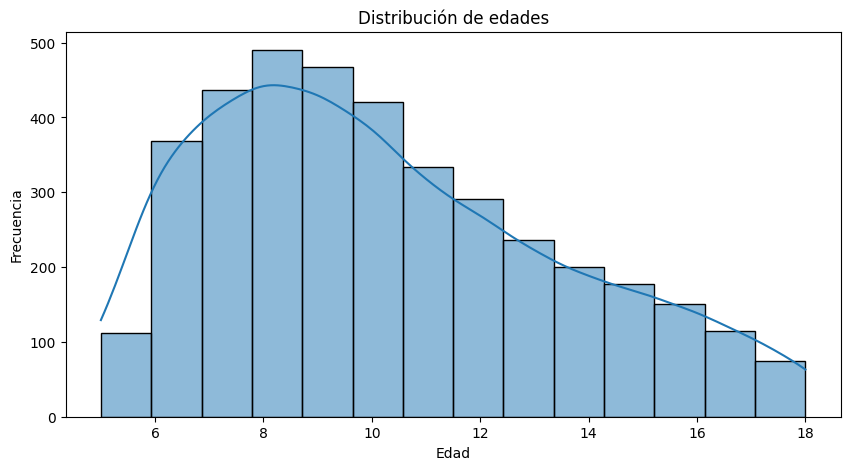

In [61]:
plt.figure(figsize=(10,5))
sns.histplot(df_reducido['Basic_Demos-Age'], bins=14, kde=True)
plt.title('Distribución de edades')
plt.xlabel('Edad')
plt.ylabel('Frecuencia')
plt.show()

**Conclusiones:**

- La distribución de edades NO es uniforme: hay un claro sesgo hacia 
  edades más jóvenes
- El pico está entre 7-9 años (~450-490 participantes por edad)
- A partir de los 10-11 años, el número de participantes disminuye 
  progresivamente hasta los 18 años (~75 participantes)
- Hay muy pocos participantes de 5 años (~110), probablemente porque 
  es el límite inferior de la muestra
- Implicación para el proyecto: el dataset representa mejor a niños 
  de primaria (7-11 años) que a adolescentes mayores (15-18 años), 
  esto hay que tenerlo en cuenta al interpretar resultados por grupo de edad

## 20. Distribución de horas de pantalla

Visualizamos cuántos participantes hay en cada categoría de uso 
de pantallas (0=menos de 1h, 1=~1h, 2=~2h, 3=más de 3h).

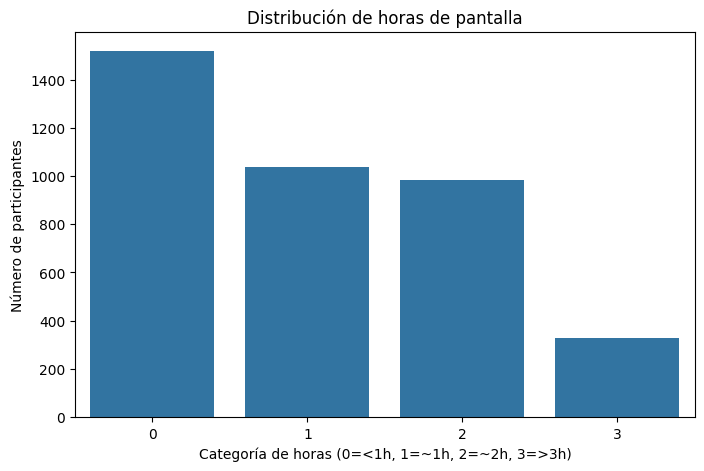

In [62]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_reducido, x='PreInt_EduHx-computerinternet_hoursday')
plt.title('Distribución de horas de pantalla')
plt.xlabel('Categoría de horas (0=<1h, 1=~1h, 2=~2h, 3=>3h)')
plt.ylabel('Número de participantes')
plt.show()

**Conclusiones:**

- La mayoría de participantes (~1.520, casi el 40%) usan pantallas 
  menos de 1h/día (categoría 0)
- Las categorías 1 (~1h) y 2 (~2h) tienen un número similar de 
  participantes (~1.040 y ~990 respectivamente)
- Solo ~330 participantes (un 8.5%) usan pantallas más de 3h/día (categoría 3)
- En conjunto, la distribución decrece a medida que aumentan las horas: 
  la mayoría del dataset tiene un uso de pantallas bajo-moderado
- Esto es relevante para el Dashboard 2: al cruzar esta variable con 
  salud mental (PCIAT, sii, CGAS, SDS), los grupos de "más de 3h" 
  tendrán menos representación (330 casos vs 1520), hay que tenerlo 
  en cuenta al interpretar diferencias entre grupos

## 21. Relación entre horas de pantalla y uso problemático de internet

Comparamos PCIAT_Total (uso problemático de internet) según la categoría 
de horas de pantalla, para ver si más horas se asocian con puntuaciones más altas.

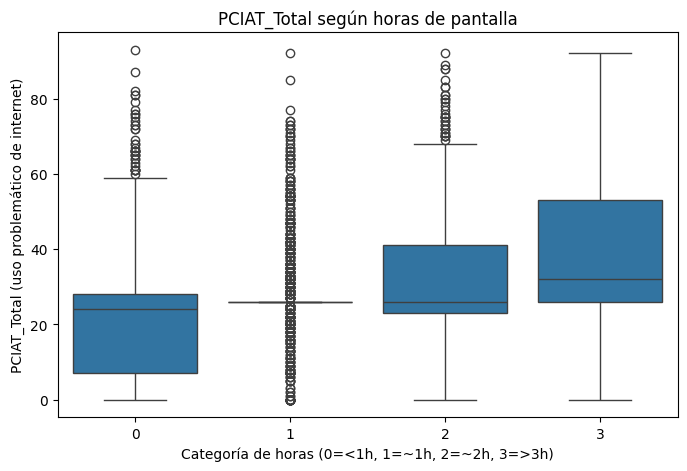

In [63]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_reducido, x='PreInt_EduHx-computerinternet_hoursday', y='PCIAT-PCIAT_Total')
plt.title('PCIAT_Total según horas de pantalla')
plt.xlabel('Categoría de horas (0=<1h, 1=~1h, 2=~2h, 3=>3h)')
plt.ylabel('PCIAT_Total (uso problemático de internet)')
plt.show()

**Conclusiones:**

- Tendencia general: a más horas de pantalla, mayor PCIAT_Total 
  (mediana sube de ~24 en categoría 0 a ~32 en categoría 3)
- Categoría 3 (>3h/día) tiene la mediana más alta y el rango 
  intercuartílico (caja) más amplio y desplazado hacia arriba (25-53)
- Categoría 1 (~1h) muestra un patrón muy raro: la caja está casi 
  "aplastada" en el valor 26, con muchísimos puntos atípicos por encima 
  y por debajo. Esto sugiere que en esta categoría hay una concentración 
  anormal de valores =26 (probablemente relacionado con la mediana que 
  usamos para imputar nulos en el paso 9, ya que 26 era justo la mediana 
  de PCIAT_Total)
- Esto es un efecto colateral de la imputación: al rellenar ~1.224 nulos 
  con el valor 26, se ha creado una "acumulación artificial" en ese valor, 
  que se concentra visualmente en la categoría 1
- Es importante mencionar esta limitación en la memoria del proyecto: 
  la imputación con mediana, aunque preserva el tamaño del dataset, 
  introduce un sesgo visible en los gráficos

## 22. Relación entre horas de pantalla y sueño (SDS)

Comparamos SDS_Total_T (problemas de sueño, a mayor valor peor sueño) 
según la categoría de horas de pantalla.

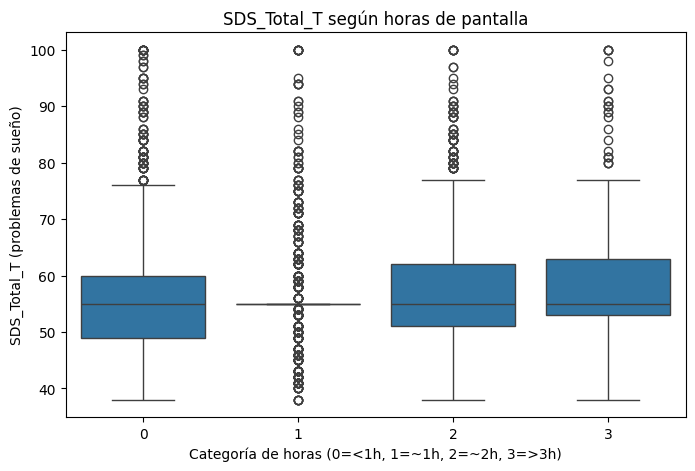

In [64]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_reducido, x='PreInt_EduHx-computerinternet_hoursday', y='SDS-SDS_Total_T')
plt.title('SDS_Total_T según horas de pantalla')
plt.xlabel('Categoría de horas (0=<1h, 1=~1h, 2=~2h, 3=>3h)')
plt.ylabel('SDS_Total_T (problemas de sueño)')
plt.show()

**Conclusiones:**

- La tendencia es mucho más débil que con PCIAT_Total: las medianas 
  de SDS_Total_T son muy similares entre categorías (~54-55 en 0 y 1, 
  ~55 en 2, ~54 en 3)
- Las cajas (rango intercuartílico) de las categorías 2 y 3 están 
  ligeramente más desplazadas hacia arriba (51-62 y 53-63) que las de 
  0 y 1, sugiriendo una leve tendencia a más problemas de sueño con más horas
- Categoría 1 muestra el mismo patrón "aplastado" que vimos en PCIAT_Total: 
  la caja colapsada en ~55 con muchos puntos atípicos, confirmando que 
  es el efecto de la imputación con mediana (SDS_Total_T también se imputó 
  con su mediana, que era 55)
- Conclusión general: las horas de pantalla parecen tener una relación 
  más fuerte con el uso problemático de internet (PCIAT) que con la 
  calidad del sueño (SDS), al menos de forma directa y lineal

## 23. Relación entre horas de pantalla y funcionamiento general (CGAS)

Comparamos CGAS_Score (a mayor valor, mejor funcionamiento/salud mental general) 
según la categoría de horas de pantalla. Aquí esperamos ver el lado 
"positivo o negativo" de las pantallas en el bienestar general.

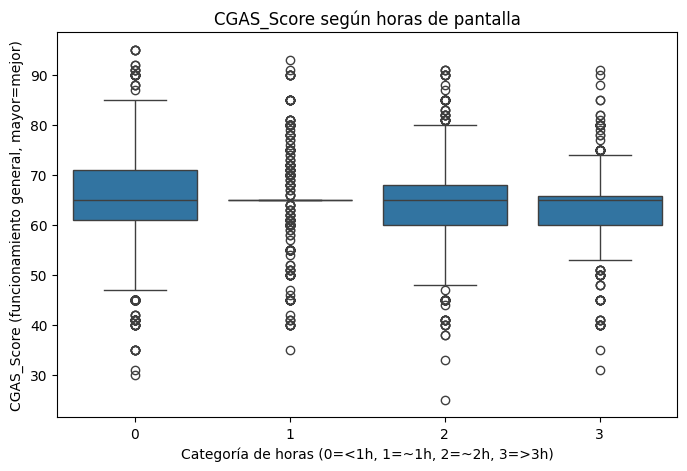

In [65]:
plt.figure(figsize=(8,5))
sns.boxplot(data=df_reducido, x='PreInt_EduHx-computerinternet_hoursday', y='CGAS-CGAS_Score')
plt.title('CGAS_Score según horas de pantalla')
plt.xlabel('Categoría de horas (0=<1h, 1=~1h, 2=~2h, 3=>3h)')
plt.ylabel('CGAS_Score (funcionamiento general, mayor=mejor)')
plt.show()

## 24. Revisión de la decisión de imputación: dropna vs mediana

Tras observar en los pasos 21-23 que la imputación con mediana genera 
concentraciones artificiales en los gráficos, volvemos a evaluar la 
decisión tomada en el paso 9: ¿cuántas filas conservaríamos si hubiéramos 
eliminado los nulos en lugar de imputarlos?

In [66]:
# Recreamos las columnas originales (antes de imputar) para comparar
columnas_relevantes = [
    'id',
    'Basic_Demos-Age',
    'Basic_Demos-Sex',
    'PreInt_EduHx-computerinternet_hoursday',
    'PCIAT-PCIAT_Total',
    'CGAS-CGAS_Score',
    'SDS-SDS_Total_T',
    'sii'
]

df_original = df[columnas_relevantes]
df_original = df_original[df_original['Basic_Demos-Age'] <= 18]

df_sin_nulos = df_original.dropna()

print('Filas con imputación:', df_reducido.shape[0])
print('Filas con dropna (datos 100% reales):', df_sin_nulos.shape[0])
print('Porcentaje conservado con dropna:', round(df_sin_nulos.shape[0] / df_original.shape[0] * 100, 1), '%')

Filas con imputación: 3872
Filas con dropna (datos 100% reales): 2118
Porcentaje conservado con dropna: 54.7 %


**Conclusiones:**

- Con imputación (mediana): 3.872 filas (100% del dataset filtrado por edad)
- Con dropna (datos 100% reales): solo 2.118 filas → se perdería un 45.3% 
  del dataset
- Esto confirma el trade-off: la imputación casi duplica el tamaño de la 
  muestra (3.872 vs 2.118), a costa de introducir ~1.750 valores artificiales 
  que generan las concentraciones observadas en los boxplots

- Decisión para el proyecto: mantenemos df_reducido (imputado, 3.872 filas) 
  como dataset principal, documentando esta limitación en la memoria. 
  Si hay tiempo, se podría repetir algún análisis clave con df_sin_nulos 
  (2.118 filas) para verificar si las conclusiones se mantienen

## 25. Distribución de sii (nivel de severidad)

Visualizamos cuántos participantes hay en cada nivel de sii 
(0=Ninguno, 1=Leve, 2=Moderado, 3=Severo).

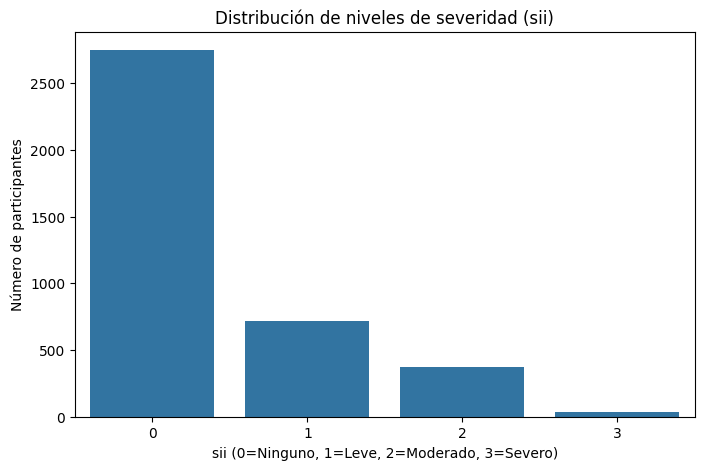

In [67]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_reducido, x='sii')
plt.title('Distribución de niveles de severidad (sii)')
plt.xlabel('sii (0=Ninguno, 1=Leve, 2=Moderado, 3=Severo)')
plt.ylabel('Número de participantes')
plt.show()

**Conclusiones:**

- La gran mayoría de participantes (~2.760, ~71%) tienen sii=0 (Ninguno), 
  es decir, sin uso problemático de internet
- sii=1 (Leve): ~730 participantes (~19%)
- sii=2 (Moderado): ~380 participantes (~10%)
- sii=3 (Severo): solo ~40 participantes (~1%)

- El dataset está muy desbalanceado hacia "sin problema" (sii=0). 
  Esto es coherente con lo visto en el paso 7 antes de la imputación
- Implicación importante para el ML futuro: si se entrena un modelo 
  para predecir sii, las clases 2 y 3 (moderado/severo) tendrán muy 
  pocos ejemplos, lo que puede dificultar que el modelo las prediga bien. 
  Habrá que tener esto en cuenta (técnicas de balanceo, métricas adecuadas 
  como F1 en lugar de accuracy, etc.)

- Para el Dashboard 2 en Tableau: este desbalance es importante mostrarlo 
  tal cual, ya que refleja la realidad — la mayoría de niños/adolescentes 
  no tienen problemas graves con el uso de pantallas, lo cual es parte 
  del mensaje "equilibrado" (positivo y negativo) que busca el proyecto

## 26. Relación entre edad y sii

Comprobamos si el nivel de severidad (sii) varía según la edad: 
¿los adolescentes mayores tienen más riesgo que los niños pequeños, 
o al revés?

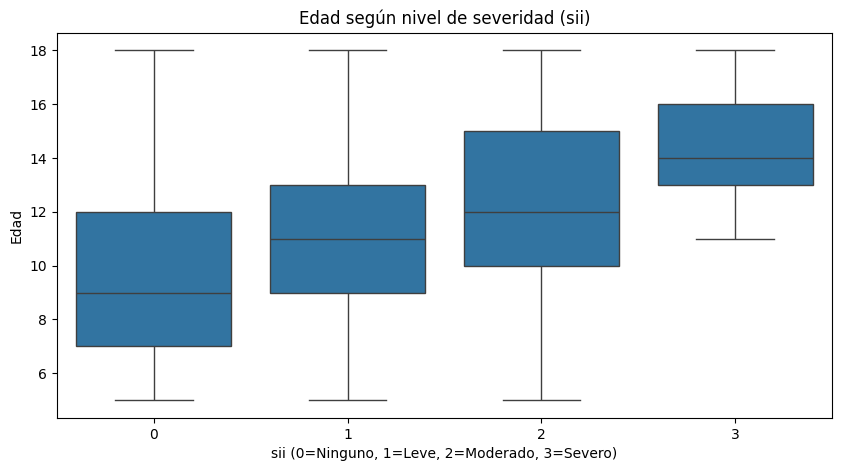

In [68]:
plt.figure(figsize=(10,5))
sns.boxplot(data=df_reducido, x='sii', y='Basic_Demos-Age')
plt.title('Edad según nivel de severidad (sii)')
plt.xlabel('sii (0=Ninguno, 1=Leve, 2=Moderado, 3=Severo)')
plt.ylabel('Edad')
plt.show()

**Conclusiones:**

- Tendencia clara y progresiva: a medida que aumenta el nivel de severidad (sii), 
  aumenta también la edad mediana de los participantes
  - sii=0 (Ninguno): mediana ~9 años (rango 7-12)
  - sii=1 (Leve): mediana ~11 años (rango 9-13)
  - sii=2 (Moderado): mediana ~12 años (rango 10-15)
  - sii=3 (Severo): mediana ~14 años (rango 13-16)

- Los adolescentes (12-18 años) están más representados en los niveles 
  de severidad altos (2 y 3) que los niños pequeños (5-9 años), que 
  predominan en el nivel 0 (sin problema)

- Esto es un hallazgo relevante para el Dashboard 2: el riesgo de uso 
  problemático de internet aumenta con la edad, lo que tiene sentido 
  (mayor acceso autónomo a dispositivos, redes sociales, etc. en la 
  adolescencia frente a la infancia)

- Para Tableau: esta relación (edad vs sii) podría ser uno de los 
  hallazgos centrales del dashboard, ya que conecta directamente con 
  la pregunta "¿qué perfil de niño/adolescente tiene mayor riesgo?"

## 27. Relación entre sexo y sii

Comprobamos si hay diferencias en el nivel de severidad (sii) 
entre niños (0=Male) y niñas (1=Female).

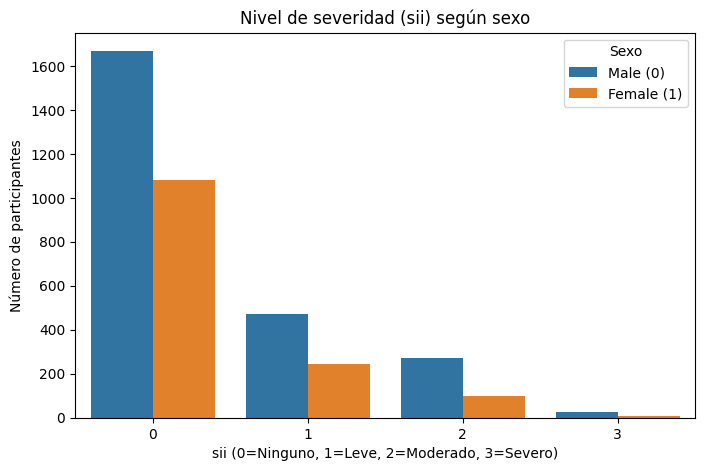

In [69]:
plt.figure(figsize=(8,5))
sns.countplot(data=df_reducido, x='sii', hue='Basic_Demos-Sex')
plt.title('Nivel de severidad (sii) según sexo')
plt.xlabel('sii (0=Ninguno, 1=Leve, 2=Moderado, 3=Severo)')
plt.ylabel('Número de participantes')
plt.legend(title='Sexo', labels=['Male (0)', 'Female (1)'])
plt.show()

**Conclusiones:**

- En todos los niveles de sii, hay más participantes masculinos (Male=0) 
  que femeninos (Female=1), lo cual es coherente con la proporción 
  general del dataset (~63% hombres, ~37% mujeres, visto en el paso 11)

- Para comparar de forma justa, hay que mirar proporciones dentro de 
  cada sexo, no solo números absolutos. A simple vista, la caída de 
  sii=0 a sii=3 parece más pronunciada en mujeres que en hombres, 
  pero esto habría que confirmarlo con porcentajes

- Aproximaciones visuales:
  - sii=0: ~1.670 hombres vs ~1.090 mujeres
  - sii=1: ~475 hombres vs ~250 mujeres  
  - sii=2: ~275 hombres vs ~100 mujeres
  - sii=3: ~30 hombres vs ~10 mujeres

- Sería útil un siguiente análisis con porcentajes (normalizado por sexo) 
  para confirmar si el riesgo relativo es distinto entre sexos, 
  o si simplemente refleja la proporción general del dataset

## 28. Proporción de sii dentro de cada sexo

Calculamos el porcentaje de cada nivel de sii dentro de cada sexo 
por separado, para comparar el riesgo relativo de forma justa 
(independientemente de que haya más hombres que mujeres en el dataset).

In [70]:
pd.crosstab(df_reducido['Basic_Demos-Sex'], df_reducido['sii'], normalize='index') * 100

sii,0,1,2,3
Basic_Demos-Sex,,,,
0,68.360656,19.426230,11.188525,1.024590
1,75.558659,17.039106,6.913408,0.488827


**Conclusiones:**

- Comparando porcentajes dentro de cada sexo:
  - Hombres (0): sii=0 → 68.4%, sii=1 → 19.4%, sii=2 → 11.2%, sii=3 → 1.0%
  - Mujeres (1): sii=0 → 75.6%, sii=1 → 17.0%, sii=2 → 6.9%, sii=3 → 0.5%

- Una mayor proporción de mujeres está en sii=0 (sin problema): 75.6% 
  vs 68.4% en hombres

- En los niveles de mayor severidad (sii=2 y sii=3), los hombres tienen 
  proporciones más altas que las mujeres:
  - sii=2: 11.2% (hombres) vs 6.9% (mujeres)
  - sii=3: 1.0% (hombres) vs 0.5% (mujeres) — el doble

- Conclusión: en este dataset, los niños/adolescentes varones muestran 
  una proporción ligeramente mayor de uso problemático de internet 
  (especialmente en niveles moderado y severo) que las niñas/adolescentes 
  mujeres. La diferencia no es enorme, pero es consistente en todos 
  los niveles de severidad

- Para Tableau: este gráfico de proporciones (normalizado) es más 
  informativo que el de conteos absolutos para comparar entre grupos 
  de tamaños distintos

## 29. Matriz de correlación entre variables numéricas

Calculamos y visualizamos las correlaciones entre todas las variables 
numéricas del dataset, para detectar relaciones que no hayamos visto 
todavía en los análisis individuales.

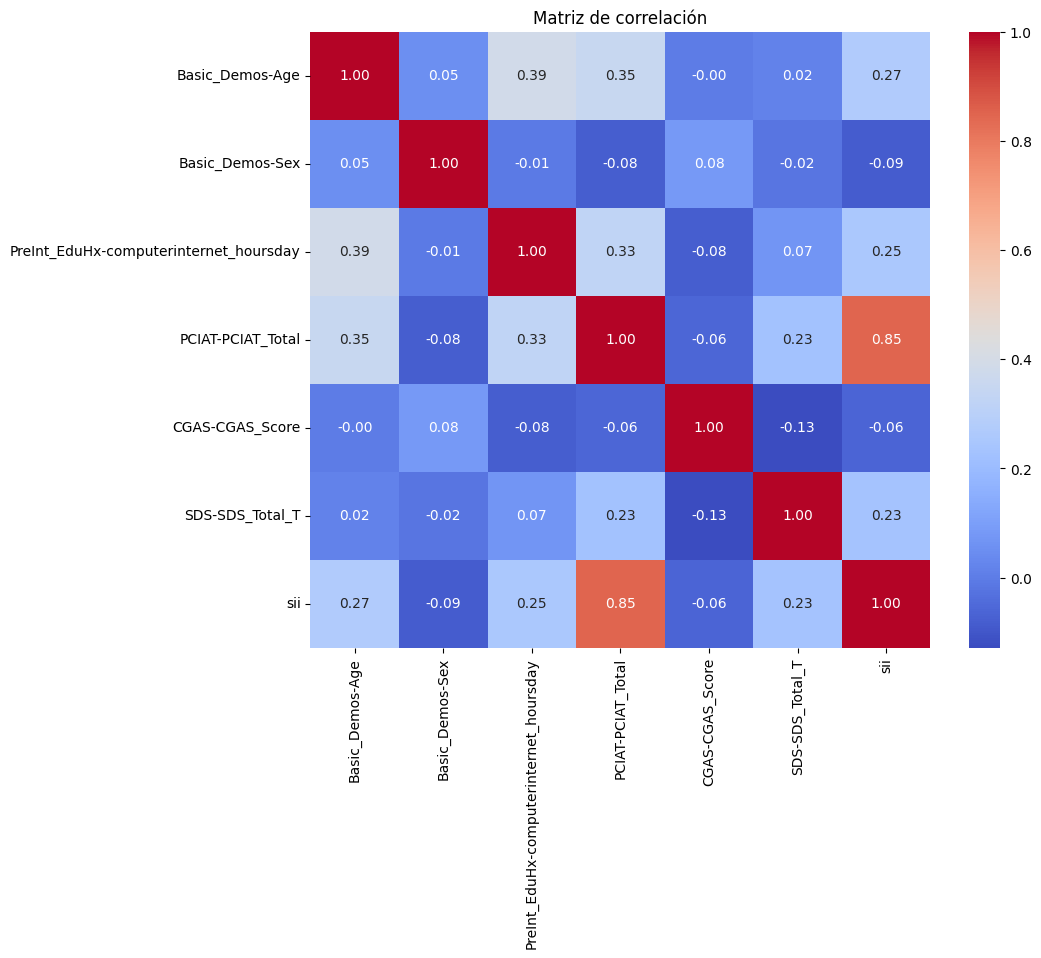

In [71]:
plt.figure(figsize=(10,8))
correlaciones = df_reducido.drop(columns='id').corr()
sns.heatmap(correlaciones, annot=True, cmap='coolwarm', fmt='.2f')
plt.title('Matriz de correlación')
plt.show()

**Conclusiones:**

- **sii y PCIAT_Total: correlación muy fuerte (0.85)** — esperado, ya que 
  sabemos que sii se deriva directamente de PCIAT_Total (paso 7)

- **Correlaciones moderadas-bajas con horas de pantalla 
  (PreInt_EduHx-computerinternet_hoursday):**
  - con PCIAT_Total: 0.33
  - con sii: 0.25
  - con edad: 0.39 (los adolescentes mayores usan más pantallas que los niños pequeños)

- **Edad (Basic_Demos-Age):**
  - correlación de 0.35 con PCIAT_Total y 0.27 con sii → confirma lo visto 
    en el paso 26 (más edad, más riesgo)

- **SDS_Total_T (sueño):**
  - correlación débil con PCIAT_Total (0.23) y con sii (0.23) → relación 
    leve, coherente con el paso 22
  - correlación negativa débil con CGAS_Score (-0.13): peor sueño se asocia 
    ligeramente con peor funcionamiento general

- **CGAS_Score:** todas sus correlaciones son muy débiles (entre -0.13 y 0.08) 
  → confirma lo visto en el paso 23, esta variable apenas se relaciona 
  linealmente con el resto

- **Sexo (Basic_Demos-Sex):** todas las correlaciones son muy débiles 
  (entre -0.09 y 0.08) → el sexo apenas tiene relación lineal directa 
  con estas variables (aunque en el paso 28 sí vimos diferencias en 
  proporciones)

- **Resumen general:** la variable con mayor poder explicativo sobre sii 
  es PCIAT_Total (por construcción), seguida de horas de pantalla y edad 
  con relaciones moderadas-débiles. El resto de variables (sexo, CGAS, sueño) 
  tienen relaciones lineales débiles con el riesgo de uso problemático de internet

## 30. Creación de columnas con etiquetas de texto

Creamos dos nuevas columnas con etiquetas legibles: Horas_Pantalla_Label 
(a partir de las categorías 0-3) y Sexo_Label (a partir de 0/1), 
para facilitar la lectura de los gráficos en Tableau.

In [72]:
horas_map = {
    0: 'Menos de 1h/día',
    1: 'Alrededor de 1h/día',
    2: 'Alrededor de 2h/día',
    3: 'Más de 3h/día'
}

sexo_map = {
    0: 'Masculino',
    1: 'Femenino'
}

df_reducido['Horas_Pantalla_Label'] = df_reducido['PreInt_EduHx-computerinternet_hoursday'].map(horas_map)
df_reducido['Sexo_Label'] = df_reducido['Basic_Demos-Sex'].map(sexo_map)

df_reducido.head()

,id,Basic_Demos-Age,Basic_Demos-Sex,PreInt_EduHx-computerinternet_hoursday,PCIAT-PCIAT_Total,CGAS-CGAS_Score,SDS-SDS_Total_T,sii,Horas_Pantalla_Label,Sexo_Label
0,00008ff9,5,0,3,55,51,55,2,Más de 3h/día,Masculino
1,000fd460,9,0,0,0,65,64,0,Menos de 1h/día,Masculino
2,00105258,10,1,2,28,71,54,0,Alrededor de 2h/día,Femenino
3,00115b9f,9,0,0,44,71,45,1,Menos de 1h/día,Masculino
4,0016bb22,18,1,1,26,65,55,0,Alrededor de 1h/día,Femenino


**Conclusiones:**

- Se añadieron correctamente 2 nuevas columnas: Horas_Pantalla_Label 
  (texto descriptivo de las 4 categorías de horas) y Sexo_Label 
  (Masculino/Femenino)
- El dataset ahora tiene 10 columnas, manteniendo las originales 
  codificadas (útiles para cálculos) y añadiendo las etiquetas 
  (útiles para visualización en Tableau)
- Nota: la fila 4 (id 0016bb22, edad 18) muestra valores que fueron 
  imputados (PreInt_EduHx=1, PCIAT_Total=26, CGAS=65, SDS=55, sii=0), 
  recordemos que originalmente esta fila tenía todos estos valores 
  como NaN (visto en el paso 4)

## 31. Identificación de un grupo de "uso saludable"

Creamos una variable que marca a los participantes con uso de pantalla 
bajo-moderado (categorías 0-1) Y buen funcionamiento general 
(CGAS_Score por encima de la mediana), para visibilizar el lado positivo 
del uso de pantallas en el Dashboard 2.

In [73]:
df_reducido['Uso_Saludable'] = (
    (df_reducido['PreInt_EduHx-computerinternet_hoursday'] <= 1) &
    (df_reducido['CGAS-CGAS_Score'] > 70)
)

df_reducido['Uso_Saludable'].value_counts()

Uso_Saludable
False    3372
True      500
Name: count, dtype: int64

**Conclusiones:**

- 500 participantes (12.9% del dataset) cumplen el criterio de "Uso_Saludable": 
  horas de pantalla bajas-moderadas (≤1h/día) Y buen funcionamiento general 
  (CGAS_Score > 70)
- 3.372 participantes (87.1%) no cumplen ambas condiciones a la vez 
  (pueden tener horas altas, CGAS bajo, o ambas cosas)
- Esta variable permite construir en Tableau un mensaje positivo: 
  "1 de cada 8 participantes combina poco tiempo de pantalla con muy 
  buen funcionamiento general", complementando el enfoque centrado 
  en sii/PCIAT (más orientado al riesgo)
- Nota: "Uso_Saludable" es una variable simplificada y compuesta por 
  el equipo, no es una medida oficial — conviene explicarlo así en 
  la memoria/dashboard

## 32. Exportación del dataset limpio para Tableau

Guardamos df_reducido (limpio, sin nulos, con etiquetas y la variable 
Uso_Saludable) en un nuevo CSV, listo para conectar con Tableau.

In [74]:
df_reducido.to_csv('Datasets/dataset_limpio_dashboard2.csv', index=False)
print('Archivo guardado correctamente')

Archivo guardado correctamente


**Conclusiones:**

- Dataset limpio exportado correctamente a Datasets/dataset_limpio_dashboard2.csv
- El archivo contiene 3.872 filas y 10 columnas: las 7 originales 
  (limpias, sin nulos, tipo int), más Horas_Pantalla_Label, Sexo_Label 
  y Uso_Saludable
- Este CSV es el que se conectará a Tableau para construir el Dashboard 2

## 📌 Conclusiones generales del EDA — Dashboard 2

### Sobre el dataset
- Partimos de 3.960 registros y 82 columnas (Child Mind Institute - 
  Problematic Internet Use)
- Tras seleccionar las 8 variables clave y filtrar por edad (0-18 años), 
  el dataset final tiene 3.872 registros y 10 columnas

### Sobre la limpieza realizada
- Se imputaron con la mediana los nulos de horas de pantalla (16.6%), 
  PCIAT_Total y sii (30.9%), CGAS_Score (38.9%) y SDS_Total_T (34.2%)
- Se recalculó sii a partir de PCIAT_Total imputado, manteniendo 
  la coherencia entre ambas variables
- Se corrigió 1 outlier en CGAS_Score (valor 999 → mediana)
- Se eliminaron 88 filas con edad >18 años (fuera del alcance del proyecto)
- Limitación documentada: la imputación introduce concentraciones 
  artificiales visibles en los gráficos (categoría "1" de horas de pantalla). 
  Con dropna se habrían conservado solo 2.118 filas (54.7% del total)

### Hallazgos principales
- **Horas de pantalla y uso problemático de internet (PCIAT)**: relación 
  positiva clara — a más horas, mayor PCIAT_Total
- **Horas de pantalla y sueño/funcionamiento general (SDS, CGAS)**: 
  relación débil o muy débil
- **Edad**: a mayor edad, mayor nivel de severidad (sii) — los adolescentes 
  muestran más riesgo que los niños pequeños
- **Sexo**: los hombres muestran proporciones algo mayores de niveles 
  moderado/severo de sii que las mujeres (11.2% vs 6.9% en moderado; 
  1.0% vs 0.5% en severo)
- **Distribución de sii**: muy desbalanceada — 71% sin problema (sii=0), 
  solo 1% severo (sii=3)
- **Correlaciones globales**: sii-PCIAT (0.85, por construcción); 
  horas de pantalla correlaciona moderadamente con edad (0.39), 
  PCIAT (0.33) y sii (0.25)

### Lado positivo
- Un 12.9% del dataset (500 participantes) combina uso de pantalla 
  bajo-moderado (≤1h/día) con buen funcionamiento general (CGAS>70), 
  variable creada como "Uso_Saludable"

### Producto final
- Dataset limpio exportado a `dataset_limpio_dashboard2.csv`, 
  listo para Tableau y para un futuro modelo de ML que prediga sii

In [75]:
df_reducido.info()

<class 'pandas.DataFrame'>
Index: 3872 entries, 0 to 3959
Data columns (total 11 columns):
 #   Column                                  Non-Null Count  Dtype
---  ------                                  --------------  -----
 0   id                                      3872 non-null   str  
 1   Basic_Demos-Age                         3872 non-null   int64
 2   Basic_Demos-Sex                         3872 non-null   int64
 3   PreInt_EduHx-computerinternet_hoursday  3872 non-null   int64
 4   PCIAT-PCIAT_Total                       3872 non-null   int64
 5   CGAS-CGAS_Score                         3872 non-null   int64
 6   SDS-SDS_Total_T                         3872 non-null   int64
 7   sii                                     3872 non-null   int64
 8   Horas_Pantalla_Label                    3872 non-null   str  
 9   Sexo_Label                              3872 non-null   str  
 10  Uso_Saludable                           3872 non-null   bool 
dtypes: bool(1), int64(7), str(3)
memo